# Canadian Housing Price Index Analysis (1981–2022)
Exploratory analysis of Canada's HPI across major regions using Python (pandas, matplotlib).

**Dataset:** CMHC Housing Price Index, monthly data 1981–2022
**Tools:** Python, pandas, matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('HPI 1981-2022 by regions.csv')
df.head()

,Unnamed: 0,Type,Month-year,Canada,Atlantic Region,Newfoundland and Labrador,Prince Edward Island,Nova Scotia,New Brunswick,Quebec,...,Manitoba,Saskatchewan,Alberta,British Columbia,"Kelowna, British Columbia","Vancouver, British Columbia","Victoria, British Columbia",Month-Year,year,month
0,0,House and Land,Jan-81,38.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,90.5,128.7,1981-01-01,1981,1
1,1,House and Land,Feb-81,38.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,92.2,130.1,1981-02-01,1981,2
2,2,House and Land,Mar-81,39.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,92.2,130.8,1981-03-01,1981,3
3,3,House and Land,Apr-81,39.9,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,91.8,130.8,1981-04-01,1981,4
4,4,House and Land,May-81,40.6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,91.8,132.5,1981-05-01,1981,5


In [3]:
df.shape
df.dtypes
df.isnull().sum()

Unnamed: 0                                  0
Type                                        0
Month-year                                  0
Canada                                      0
Atlantic Region                           180
Newfoundland and Labrador                 180
Prince Edward Island                      504
Nova Scotia                               180
New Brunswick                             180
Quebec                                    180
Quebec City, Quebec                         0
Sherbrooke, Quebec                       1293
Trois-Rivieres, Quebec                   1293
Montreal, Quebec                            0
Ottawa-Gatineau, Quebec part             1293
Ontario                                   180
Ottawa-Gatineau, Ontario part               0
Oshawa, Ontario                          1293
Toronto, Ontario                            0
Hamilton, Ontario                           0
St. Catharines-Niagara, Ontario             0
Kitchener-Cambridge-Waterloo, Onta

## Data Cleaning
Filter to 'House and Land' property type only. Convert date column to datetime format.

In [4]:
df['Month-Year'] = pd.to_datetime(df['Month-Year'])

In [5]:
df = df[df['Type'] == 'House and Land']

In [6]:
df.shape

(498, 37)

## Q1: How has Canada's national HPI trended over 40 years?

<Figure size 864x360 with 0 Axes>

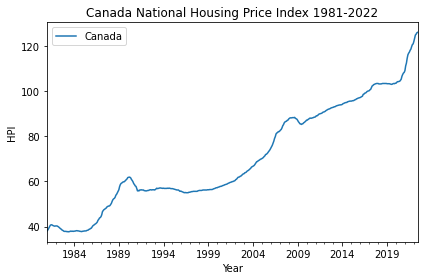

In [7]:
plt.figure(figsize=(12, 5))
df.plot(x='Month-Year', y='Canada', kind='line')
plt.title('Canada National Housing Price Index 1981-2022')
plt.xlabel('Year')
plt.ylabel('HPI')
plt.tight_layout()
plt.show()

Canadian HPI nearly tripled from ~40 in 1981 to ~128 in 2022. Two notable crashes: the late 1980s bubble burst (1991) and the 2008 financial crisis. The post-2020 COVID surge was the sharpest in the dataset's history.

## Q2: How do Toronto, Vancouver, and Alberta compare over time?

<Figure size 864x360 with 0 Axes>

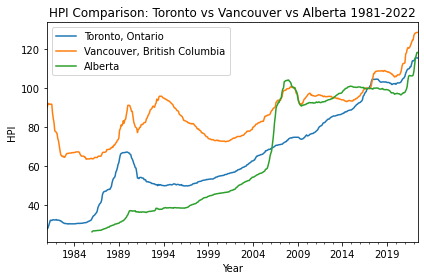

In [11]:
plt.figure(figsize=(12, 5))
df.plot(x='Month-Year', y=['Toronto, Ontario', 'Vancouver, British Columbia', 'Alberta'], kind='line')
plt.title('HPI Comparison: Toronto vs Vancouver vs Alberta 1981-2022')
plt.xlabel('Year')
plt.ylabel('HPI')
plt.tight_layout()
plt.show()

Vancouver consistently led in HPI from 1981, driven by early demand and two major boom-bust cycles (late 1980s and mid-2000s). Alberta's surge between 2005–2008 directly tracks the oil boom, followed by a sharp decline when oil prices fell. All three regions converged sharply post-2020, suggesting the COVID-era housing surge erased historical regional differences in price levels.

## Q3: Which region had the biggest post-2020 (COVID-era) price surge?

In [14]:
post_covid=df[df['year']> 2019]

In [26]:
Alberta_change= post_covid['Alberta'].iloc[-1]-post_covid['Alberta'].iloc[0]  # last value-first value
print("Alberta change: ",Alberta_change)

Alberta change:  21.200000000000003


In [27]:
Vancouver_change= post_covid['Vancouver, British Columbia'].iloc[-1]-post_covid['Vancouver, British Columbia'].iloc[0]  # last-first value
print("Vancouver change: ",Vancouver_change)

Vancouver change:  22.69999999999999


In [28]:
Toronto_change= post_covid['Toronto, Ontario'].iloc[-1]-post_covid['Toronto, Ontario'].iloc[0]  #last-first value
print("Toronto change: ",Toronto_change)

Toronto change:  13.5


Vancouver saw the largest HPI increase post-2020 (+22.7 points), followed closely by Alberta (+21.2 points). Toronto's surge was smaller (+13.5 points), likely because it was already at a high baseline before COVID. Alberta's strong surge is notable given its flat/declining period since 2008, suggesting renewed demand driven by interprovincial migration from expensive Ontario and BC markets.

## Q4: What does Toronto's year-over-year HPI growth rate reveal?

In [48]:
toronto_yoy=df.groupby('year')['Toronto, Ontario'].mean().pct_change()*100; #Creating a dataframe to show percentage change

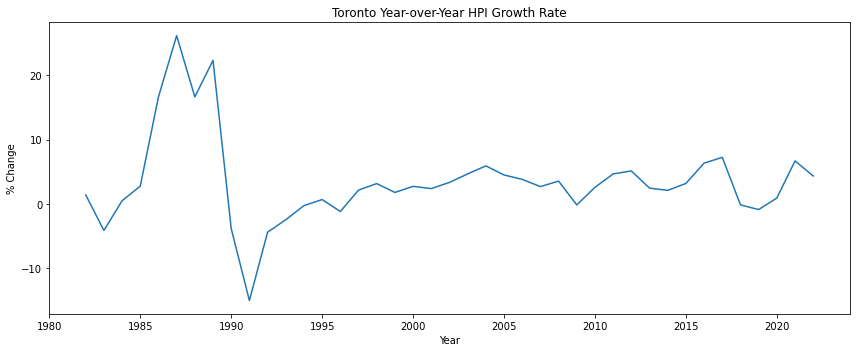

In [50]:
#plot the result directly
plt.figure(figsize=(12, 5))
toronto_yoy.plot(kind='line')
plt.title('Toronto Year-over-Year HPI Growth Rate')
plt.xlabel('Year')
plt.ylabel('% Change')
plt.tight_layout()
plt.show()

Toronto's sharpest growth occurred during the late 1980s housing bubble, peaking at ~27% year-over-year, followed by a dramatic crash to -15% in 1991 when high interest rates burst the bubble. From the mid-1990s onward, growth stabilized at a modest 2–5% annually. The post-2020 surge reached ~7% before declining in 2021–2022, confirming a year-over-year price drop as the market cooled after the COVID spike.